<a href="https://colab.research.google.com/github/vsoto89/Etapa_3_inte/blob/main/IEI095_Avance3_Limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

archivos = [
    '/content/drive/MyDrive/dataset_ventas_1.xlsx',
    '/content/drive/MyDrive/dataset_ventas_2.xlsx',
    '/content/drive/MyDrive/dataset_ventas_3.xlsx'
]
print("Librerías importadas y rutas definidas.")

Librerías importadas y rutas definidas.


In [2]:
# =====================================================================
# PIPELINE ETL: INGESTA, MERGE, LIMPIEZA TRANSACCIONAL Y DIAGNÓSTICO
# =====================================================================

lista_tablas_planas = []

# 1. Leemos y ensamblamos archivo por archivo
for ruta in archivos:
    v = pd.read_excel(ruta, sheet_name='Fact_Ventas')
    c = pd.read_excel(ruta, sheet_name='Dim_Clientes')
    p = pd.read_excel(ruta, sheet_name='Dim_Productos')
    s = pd.read_excel(ruta, sheet_name='Dim_Sucursales')

    # Adaptador de IDs y cruces
    tabla_plana = pd.merge(v, c, left_on='Cliente_ID', right_on='ID', how='left')
    tabla_plana = tabla_plana.drop(columns=['ID'])
    tabla_plana = pd.merge(tabla_plana, p, on='Producto_ID', how='left')
    tabla_plana = pd.merge(tabla_plana, s, on='Sucursal_ID', how='left')

    lista_tablas_planas.append(tabla_plana)

# 2. Apilamos todo en la placa base final (15.000 filas iniciales)
df_final = pd.concat(lista_tablas_planas, ignore_index=True)

# 3. LA REGLA DE VÍCTOR: LIMPIEZA DE TRANSACCIONES DUPLICADAS POR ERROR DE SISTEMA
# Filtramos directamente df_final comparando Nombre + Ciudad + Fecha + Producto
filas_antes = len(df_final)
df_final = df_final.drop_duplicates(subset=['Nombre_Completo', 'Ciudad_Base', 'Fecha', 'Producto_ID'])
filas_despues = len(df_final)
errores_eliminados = filas_antes - filas_despues

# 4. Estadísticas descriptivas (Contar personas reales)
clientes_unicos = df_final.drop_duplicates(subset=['Nombre_Completo', 'Ciudad_Base'])

print("¡Esquema Estrella unificado y limpieza transaccional aplicada!")
print("-" * 50)
print(f"Transacciones iniciales (con posibles errores): {filas_antes}")
print(f"Boletas duplicadas por error del sistema eliminadas: {errores_eliminados}")
print(f"Total Ventas Oficiales y Limpias: {filas_despues}")
print(f"Total Clientes Únicos Reales: {len(clientes_unicos)}")
print("-" * 50)
print("DIAGNÓSTICO DE CALIDAD DE DATOS (Nulos):")
print(df_final.isnull().sum())

¡Esquema Estrella unificado y limpieza transaccional aplicada!
--------------------------------------------------
Transacciones iniciales (con posibles errores): 15000
Boletas duplicadas por error del sistema eliminadas: 564
Total Ventas Oficiales y Limpias: 14436
Total Clientes Únicos Reales: 275
--------------------------------------------------
DIAGNÓSTICO DE CALIDAD DE DATOS (Nulos):
Venta_ID                        0
Fecha                           0
Cliente_ID                      0
Producto_ID                     0
Sucursal_ID                     0
Cantidad                        0
Precio_Unitario_CLP             0
Descuento_Aplicado_CLP          0
Monto_Total_CLP                 0
API_Clima_Temp_C                0
API_Clima_Condicion             0
API_Despacho_Entrega_Minutos    0
Nombre_Completo                 0
Genero                          0
Ciudad_Base                     0
Region_Base                     0
Nombre                          0
Categoría                      

In [3]:
# =====================================================================
# TRANSFORMACIÓN FASE 2: FORMATOS Y VALORES ATÍPICOS
# =====================================================================

print("Iniciando limpieza fina...")

# 1. HOMOLOGACIÓN DE TEXTO
# Convertimos el clima a minúsculas (.str.lower()) y quitamos espacios fantasma (.str.strip())
df_final['API_Clima_Condicion'] = df_final['API_Clima_Condicion'].str.lower().str.strip()

# Verificamos cómo quedaron escritos los climas para asegurar que no hay duplicados lógicos
print("\nTipos de clima detectados después de la limpieza:")
print(df_final['API_Clima_Condicion'].unique())

# 2. DIAGNÓSTICO DE VALORES ATÍPICOS (Outliers)
# Seleccionamos solo las columnas numéricas críticas que podrían tener errores graves
columnas_auditoria = ['API_Clima_Temp_C', 'API_Despacho_Entrega_Minutos']

print("\n--- ESCÁNER ESTADÍSTICO (Buscando anomalías) ---")
# .describe() nos mostrará el Mínimo, Máximo y Promedio de esas columnas
print(df_final[columnas_auditoria].describe())

Iniciando limpieza fina...

Tipos de clima detectados después de la limpieza:
['despejado' 'lluvia fuerte' 'nublado']

--- ESCÁNER ESTADÍSTICO (Buscando anomalías) ---
       API_Clima_Temp_C  API_Despacho_Entrega_Minutos
count      14436.000000                  14436.000000
mean          14.125173                     50.208576
std            6.754484                     19.689662
min           -5.000000                     15.000000
25%            9.000000                     37.000000
50%           14.000000                     48.000000
75%           19.000000                     61.000000
max           39.000000                    168.000000


In [4]:
# =====================================================================
# TRANSFORMACIÓN FASE 3: FILTRADO DE VALORES ATÍPICOS (OUTLIERS)
# =====================================================================

print(f"Filas antes del filtro de atípicos: {len(df_final)}")

# 1. Definimos las reglas del "Filtro Pasa-Banda"
# El símbolo '&' significa 'Y' (ambas condiciones deben cumplirse)
filtro_minutos = (df_final['API_Despacho_Entrega_Minutos'] >= 0) & (df_final['API_Despacho_Entrega_Minutos'] <= 300)
filtro_temperatura = (df_final['API_Clima_Temp_C'] >= -15) & (df_final['API_Clima_Temp_C'] <= 50)

# 2. Aplicamos la máscara a la tabla principal
# Le decimos a Pandas: "De df_final, quédate SOLO con las filas que aprueben ambos filtros"
df_final = df_final[filtro_minutos & filtro_temperatura]

# 3. Reiniciamos el índice (para que la numeración de las filas quede perfecta tras borrar datos)
df_final = df_final.reset_index(drop=True)

print(f"Filas después del filtro de atípicos: {len(df_final)}")
print("-" * 50)
print("¡Fase de Transformación (ETL) 100% Completada!")

Filas antes del filtro de atípicos: 14436
Filas después del filtro de atípicos: 14436
--------------------------------------------------
¡Fase de Transformación (ETL) 100% Completada!


Generando Matriz de Correlación para el Avance #3...
¡Imagen guardada exitosamente como 'mapa_correlacion_Avance3.png'!


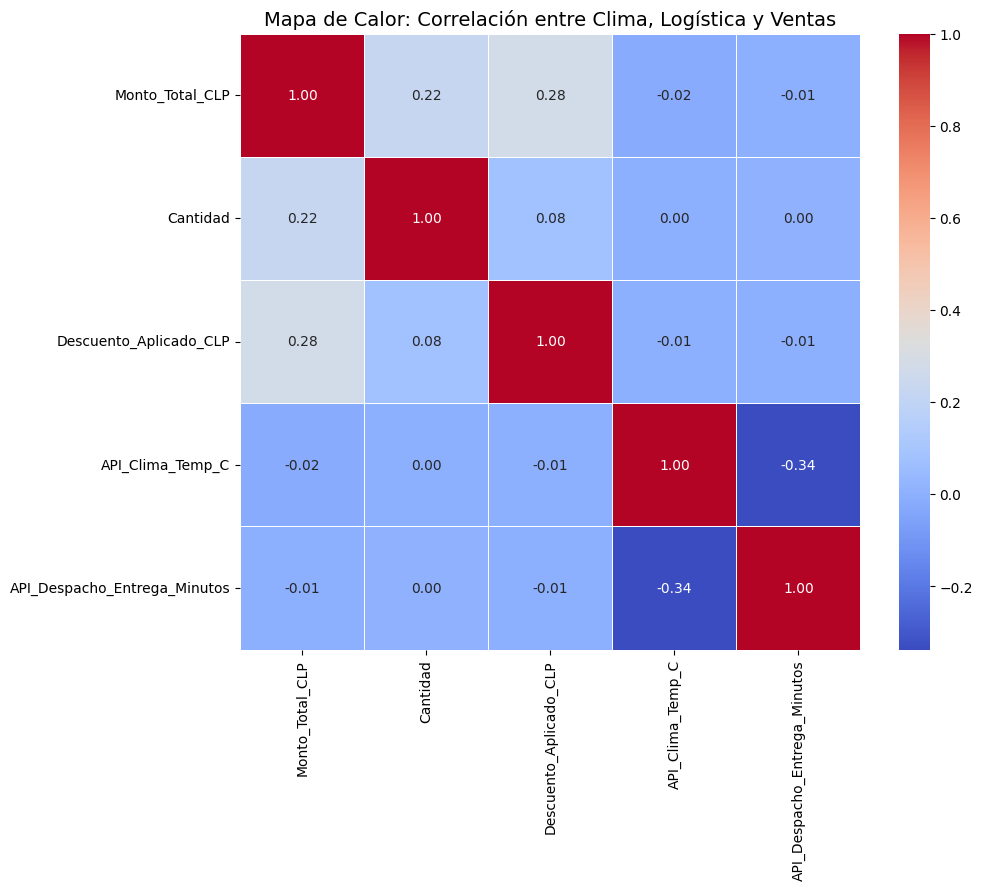

In [5]:
# =====================================================================
# FASE 2 (EDA): MATRIZ DE CORRELACIÓN VISUAL (HEATMAP)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando Matriz de Correlación para el Avance #3...")

# 1. Seleccionamos SOLO las variables numéricas clave del Avance #2
columnas_correlacion = [
    'Monto_Total_CLP',
    'Cantidad',
    'Descuento_Aplicado_CLP',
    'API_Clima_Temp_C',
    'API_Despacho_Entrega_Minutos'
]

# Creamos un sub-dataframe solo con esas columnas
df_numerico = df_final[columnas_correlacion]

# 2. Calculamos la matriz de correlación matemática (Pearson)
matriz_corr = df_numerico.corr()

# 3. Configuramos el lienzo del gráfico
plt.figure(figsize=(10, 8))
plt.title("Mapa de Calor: Correlación entre Clima, Logística y Ventas", fontsize=14)

# 4. Generamos el Heatmap con Seaborn
# annot=True muestra los números, cmap='coolwarm' da colores rojo (positivo) / azul (negativo)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 5. GUARDAR LA IMAGEN PARA EL REPORTE (¡Nueva línea para el Avance 3!)
plt.savefig("mapa_correlacion_Avance3.png", bbox_inches='tight', dpi=300)
print("¡Imagen guardada exitosamente como 'mapa_correlacion_Avance3.png'!")

# Mostramos el gráfico en pantalla
plt.show()

Iniciando entrenamiento del motor predictivo...

--- RESULTADOS DEL MODELO ---
Coeficiente de impacto (Pendiente): -0.98
Precisión del modelo (R2): 0.11


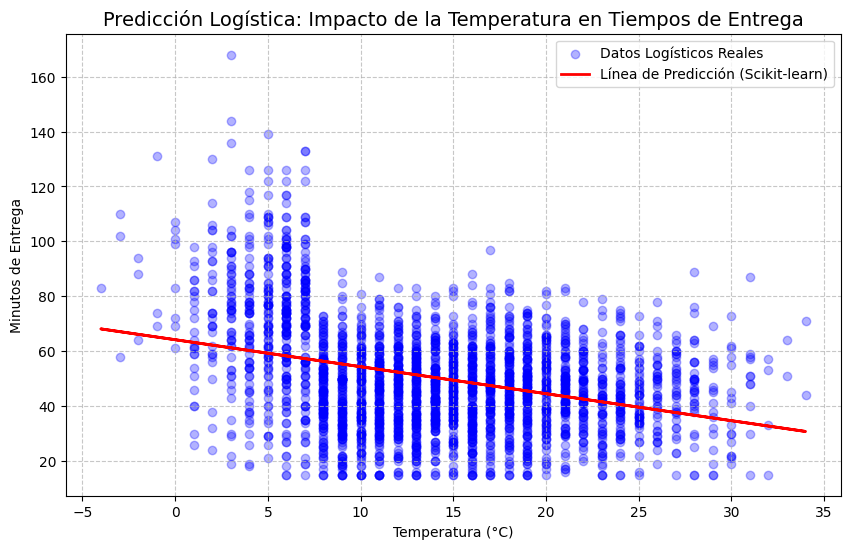


¡Gráfico guardado exitosamente como 'regresion_lineal_Avance3.png'!


In [6]:
# =====================================================================
# FASE 3: MODELADO PREDICTIVO - REGRESIÓN LINEAL
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("Iniciando entrenamiento del motor predictivo...\n")

# 1. Definir variables (X = predictor (Temperatura), y = objetivo (Minutos))
X = df_final[['API_Clima_Temp_C']]
y = df_final['API_Despacho_Entrega_Minutos']

# 2. Dividir los datos: 80% para entrenar la máquina, 20% para probarla a ciegas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inicializar y conectar el algoritmo
modelo_regresion = LinearRegression()

# 4. Fase de Entrenamiento (Aquí ocurre el Machine Learning)
modelo_regresion.fit(X_train, y_train)

# 5. Hacer predicciones con el 20% de datos que la máquina nunca ha visto
predicciones = modelo_regresion.predict(X_test)

# 6. Extraer las métricas clave de rendimiento
precision_r2 = r2_score(y_test, predicciones)
coeficiente = modelo_regresion.coef_[0]

print("--- RESULTADOS DEL MODELO ---")
print(f"Coeficiente de impacto (Pendiente): {coeficiente:.2f}")
print(f"Precisión del modelo (R2): {precision_r2:.2f}")

# 7. Generar el gráfico de evidencia para el informe
plt.figure(figsize=(10, 6))
# Dibujamos los datos reales como puntos azules
plt.scatter(X_test, y_test, color='blue', alpha=0.3, label='Datos Logísticos Reales')
# Dibujamos la predicción matemática como una línea roja
plt.plot(X_test, predicciones, color='red', linewidth=2, label='Línea de Predicción (Scikit-learn)')

plt.title('Predicción Logística: Impacto de la Temperatura en Tiempos de Entrega', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Minutos de Entrega')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 8. Guardar la imagen para tu documento de Word
plt.savefig("regresion_lineal_Avance3.png", bbox_inches='tight', dpi=300)
plt.show()

print("\n¡Gráfico guardado exitosamente como 'regresion_lineal_Avance3.png'!")